In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split 

from src.data_processing import clean_text
from src.bag_of_words import NumpyBagOfWords

df = pd.read_csv("../data/processed/dataset_kaggle_daigt_processed.csv", sep=";")

label_map = {label: i for i, label in enumerate(df['Label'].unique())}
df['label_id'] = df['Label'].map(label_map)

df['text_clean'] = df['Text'].apply(clean_text)

X_train, X_val, y_train, y_val = train_test_split(
    df['text_clean'], df['label_id'], test_size=0.2, random_state=42
)

bow = NumpyBagOfWords(max_words=2500)

X_train_num = bow.fit_transform(X_train.tolist())
X_val_num = bow.transform(X_val.tolist())

Y_train_num = np.array(y_train)
Y_val_num = np.array(y_val)

os.makedirs("../submissions/submissao1", exist_ok=True)
bow.save("../submissions/submissao1/bow_model.pkl")

print(f"Matriz de Treino (Linhas, Colunas): {X_train_num.shape}")

Matriz de Treino (Linhas, Colunas): (2151, 2500)


Epoch 10/100 | Loss: 0.4950 Acc: 0.8582 | Val Loss: 0.4458 Val Acc: 0.8476
Epoch 20/100 | Loss: 0.2592 Acc: 0.9028 | Val Loss: 0.3155 Val Acc: 0.8866
Epoch 30/100 | Loss: 0.1790 Acc: 0.9349 | Val Loss: 0.2588 Val Acc: 0.9126
Epoch 40/100 | Loss: 0.1341 Acc: 0.9549 | Val Loss: 0.2311 Val Acc: 0.9219
Epoch 50/100 | Loss: 0.1029 Acc: 0.9702 | Val Loss: 0.2301 Val Acc: 0.9219
Epoch 60/100 | Loss: 0.0802 Acc: 0.9791 | Val Loss: 0.2260 Val Acc: 0.9238
Epoch 70/100 | Loss: 0.0632 Acc: 0.9856 | Val Loss: 0.2259 Val Acc: 0.9275
Epoch 80/100 | Loss: 0.0504 Acc: 0.9907 | Val Loss: 0.2293 Val Acc: 0.9294
Epoch 90/100 | Loss: 0.0407 Acc: 0.9940 | Val Loss: 0.2328 Val Acc: 0.9294
Epoch 100/100 | Loss: 0.0333 Acc: 0.9949 | Val Loss: 0.2366 Val Acc: 0.9294


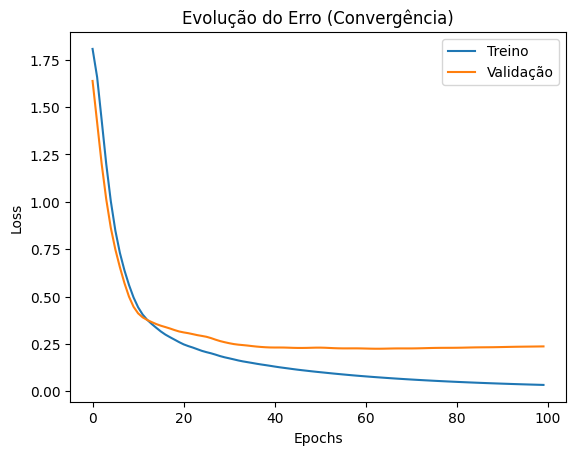

In [3]:
from src.models_numpy.dnn.neuralnet import NeuralNetwork
from src.models_numpy.dnn.layers import DenseLayer
from src.models_numpy.dnn.activation import ReLUActivation, SoftmaxActivation
from src.models_numpy.dnn.losses import CategoricalCrossEntropy
from src.models_numpy.dnn.optimizer import SGD

num_classes = 6
Y_train_onehot = np.eye(num_classes)[Y_train_num]
Y_val_onehot = np.eye(num_classes)[Y_val_num]

model = NeuralNetwork()
model.add(DenseLayer(input_size=2500, output_size=128))
model.add(ReLUActivation())
model.add(DenseLayer(input_size=128, output_size=64))
model.add(ReLUActivation())
model.add(DenseLayer(input_size=64, output_size=num_classes))
model.add(SoftmaxActivation())

model.compile(loss_func=CategoricalCrossEntropy(), optimizer=SGD(learning_rate=0.01))

history = model.fit(
    X_train_num, Y_train_onehot, 
    epochs=100, 
    val_data=(X_val_num, Y_val_onehot)
)

plt.plot(history['train_loss'], label='Treino')
plt.plot(history['val_loss'], label='Validação')
plt.title('Evolução do Erro (Convergência)')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend()
plt.show()

model.save("../submissions/submissao1/dnn_weights.pkl")